# Harmonic plus Stochastic (HPS) Model Example

Demonstrates the **HPS Model**, which separates a sound into a harmonic component and a stochastic (noise) component:
1. Load audio and inspect the waveform
2. Analyse with the HPS model, resynthesize, and inspect all three components (full output, harmonics, stochastic)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.signal import get_window
from smstools.models import utilFunctions as UF
from smstools.models import hpsModel as HPS
import plot_helpers as PH

PH.setup_plot_style()

## 1) Load audio and inspect waveform

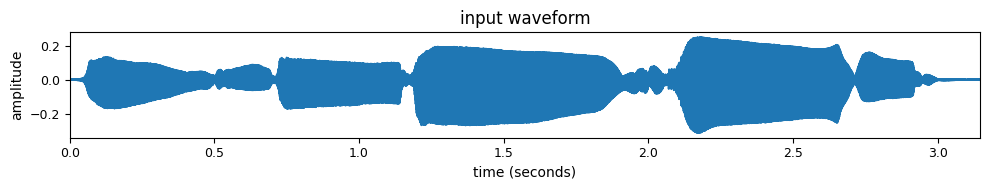

In [12]:
input_file = '../sounds/sax-phrase-short.wav'
fs, x = UF.wavread(input_file)

fig, ax = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax, x, fs, title='input waveform', xlabel='time (seconds)')
plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(data=x, rate=fs))

## 2) HPS model analysis and synthesis

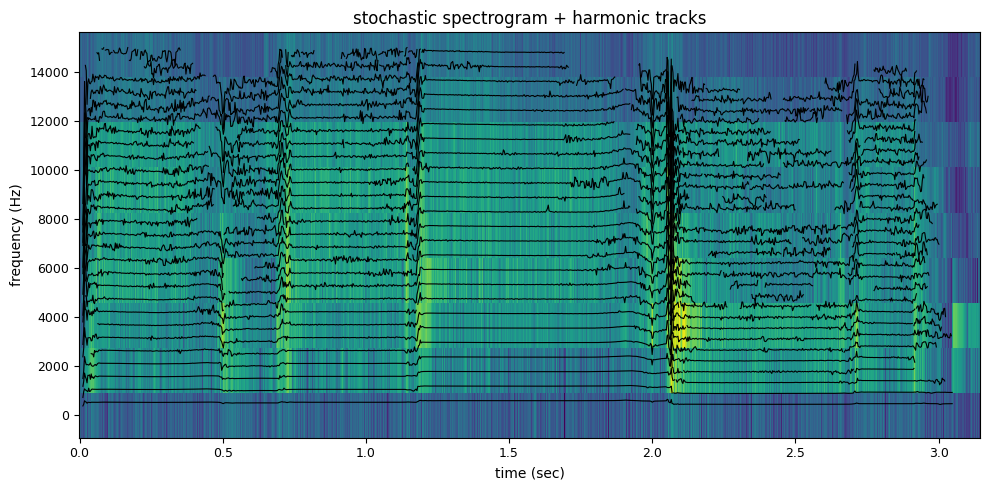

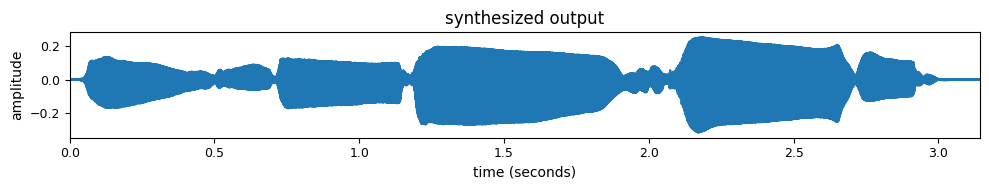

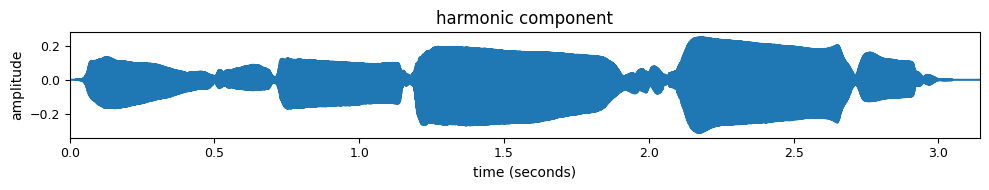

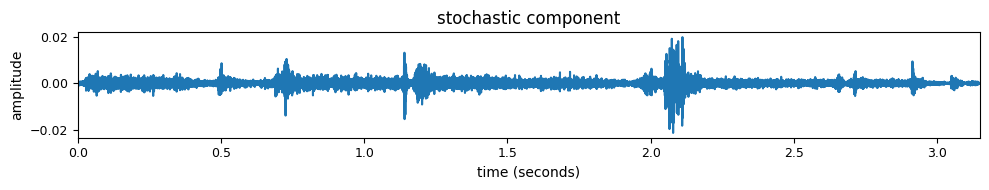

In [13]:
# analysis / synthesis parameters
window = 'blackman'
M = 601
N = 1024
t = -100
min_sine_dur = 0.1
n_harmonics = 100
min_f0 = 350
max_f0 = 700
f0_error_threshold = 5
harm_dev_slope = 0.01
stoc_factor = 0.1
Ns = 512    # FFT size for synthesis
H = 128     # hop size (must be Ns/4)
max_plot_freq = 15000.0

w = get_window(window, M)
hfreq, hmag, hphase, stoc_env = HPS.hpsModelAnal(
    x, fs, w, N, H, t, n_harmonics, min_f0, max_f0,
    f0_error_threshold, harm_dev_slope, min_sine_dur, Ns, stoc_factor
)
y, yh, yst = HPS.hpsModelSynth(hfreq, hmag, hphase, stoc_env, Ns, H, fs)

# --- stochastic spectrogram with harmonic overlay ---
env_size = stoc_env.shape[1]
fig, ax = plt.subplots(figsize=(10, 5))
PH.plot_spectrogram_with_tracks(ax, stoc_env, hfreq, fs, 2 * env_size, H, max_plot_freq=max_plot_freq, title='stochastic spectrogram + harmonic tracks')
plt.tight_layout()
plt.show()

# --- full synthesized output ---
fig2, ax2 = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax2, y, fs, title='synthesized output', xlabel='time (seconds)')
plt.tight_layout()
plt.show()
ipd.display(ipd.Audio(data=y, rate=fs, normalize=False))

# --- harmonic component ---
fig3, ax3 = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax3, yh, fs, title='harmonic component', xlabel='time (seconds)')
plt.tight_layout()
plt.show()
ipd.display(ipd.Audio(data=yh, rate=fs, normalize=False))

# --- stochastic component ---
fig4, ax4 = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax4, yst, fs, title='stochastic component', xlabel='time (seconds)')
plt.tight_layout()
plt.show()
ipd.display(ipd.Audio(data=yst, rate=fs, normalize=False))

## 3) Single-frame HPS analysis and synthesis

This section shows HPS processing on one analysis frame:

1. Original magnitude spectrum.
2. Detected harmonic peaks.
3. Synthesized harmonic spectrum from the tracked harmonics.
4. Stochastic spectrum approximation.
5. Spectrum of the reconstructed frame (harmonic + stochastic).


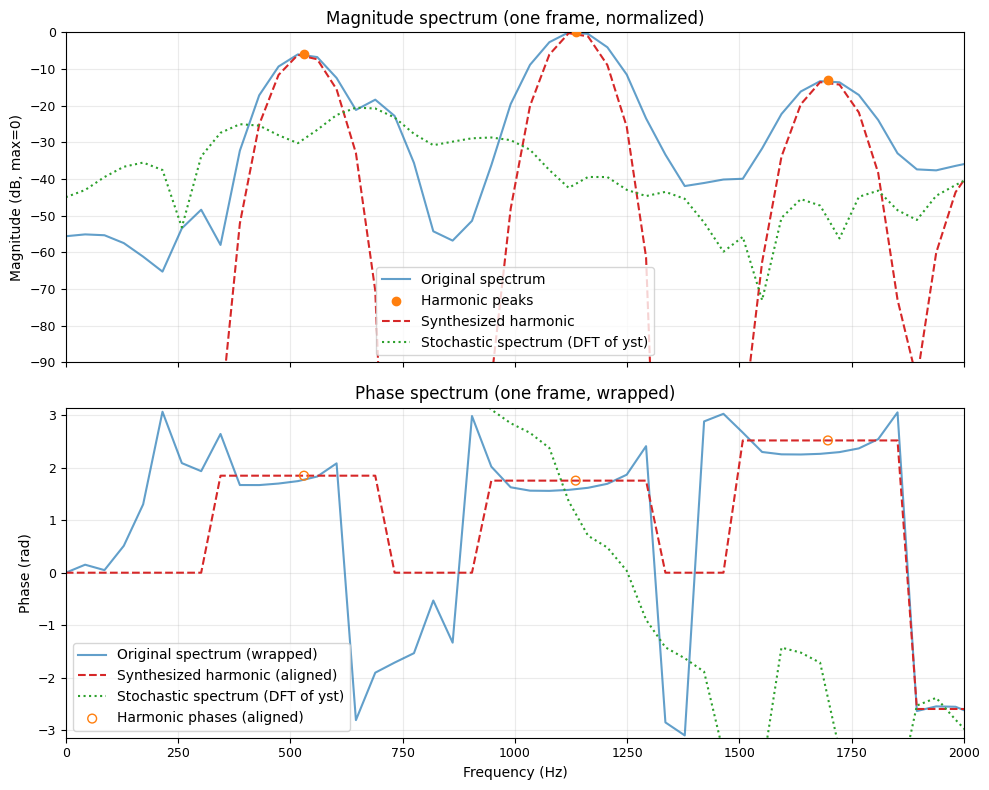

In [14]:
# Single frame for HPS analysis/synthesis, using computed frame closest to chosen time
frame_time = 2.0  # desired time in seconds
frame_idx = int(np.round(frame_time * fs / H))
frame_idx = np.clip(frame_idx, 0, hfreq.shape[0] - 1)  # ensure within valid range
t_frame = frame_idx * H / fs  # actual time of the chosen analysis frame
pin = frame_idx * H
hM1 = (M + 1) // 2
hM2 = M // 2
if pin - hM1 < 0 or pin + hM2 > len(x):
    raise ValueError('Selected frame is outside the signal range')

x_frame = x[pin - hM1:pin + hM2]
yh_frame = yh[pin - hM1:pin + hM2]
yst_frame = yst[pin - hM1:pin + hM2]

# DFT of the original, harmonic, and stochastic frames
from smstools.models import dftModel as DFT
mX_frame, pX_frame = DFT.dftAnal(x_frame, w, N)
mYh_frame, pYh_frame = DFT.dftAnal(yh_frame, w, N)
mYst_frame, pYst_frame = DFT.dftAnal(yst_frame, w, N)
freq_axis = fs * np.arange(mX_frame.size) / float(N)
hNs = N // 2

# Use the already computed harmonic peaks for this frame
hfreq_frame = hfreq[frame_idx]
hmag_frame = hmag[frame_idx]
hphase_frame = hphase[frame_idx]
valid = hfreq_frame > 0
hfreq_frame = hfreq_frame[valid]
hmag_frame = hmag_frame[valid]
hphase_frame = hphase_frame[valid]

# Wrap harmonic phases to [-pi, pi]
hphase_wrapped = np.angle(np.exp(1j * hphase_frame))

# Use wrapped phase for original spectrum as well
pX_wrapped = np.angle(np.exp(1j * pX_frame[:hNs]))

# Compute original phase at harmonic frequencies (from DFT)
orig_phase_at_harm = np.interp(hfreq_frame, freq_axis[:hNs], pX_wrapped)

# Align harmonic phases to DFT reference (minimize pi difference)
phase_diff = hphase_wrapped - orig_phase_at_harm
phase_diff = np.mod(phase_diff + np.pi, 2 * np.pi) - np.pi  # wrap to [-pi, pi]
hphase_aligned = hphase_wrapped.copy()
hphase_aligned[phase_diff < -np.pi/2] += np.pi
hphase_aligned[phase_diff > np.pi/2] -= np.pi
hphase_aligned = np.angle(np.exp(1j * hphase_aligned))  # wrap again

# Align synthesized phases to DFT reference (same as harmonic phases)
from smstools.models.utilFunctions import genSpecSines
Yharm = genSpecSines(hfreq_frame, hmag_frame, hphase_aligned, N, fs)
mag_harm = 20 * np.log10(np.abs(Yharm[:hNs]) + 1e-12)
phase_harm = np.angle(Yharm[:hNs])  # use aligned phase

# Normalize all spectra to the maximum magnitude of the original frame
max_mag = np.max(mX_frame[:hNs])
mX_frame_norm = mX_frame[:hNs] - max_mag
mag_harm_norm = mag_harm - max_mag
mYst_frame_norm = mYst_frame[:hNs] - max_mag

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Magnitude spectrum
axes[0].plot(freq_axis[:hNs], mX_frame_norm, label='Original spectrum', color='tab:blue', alpha=0.7)
axes[0].scatter(hfreq_frame, hmag_frame - max_mag, color='tab:orange', label='Harmonic peaks', zorder=5)
axes[0].plot(freq_axis[:hNs], mag_harm_norm, label='Synthesized harmonic', color='tab:red', linestyle='--')
axes[0].plot(freq_axis[:hNs], mYst_frame_norm, label='Stochastic spectrum (DFT of yst)', color='tab:green', linestyle=':')
axes[0].set_title('Magnitude spectrum (one frame, normalized)')
axes[0].set_ylabel('Magnitude (dB, max=0)')
axes[0].set_ylim([-90, 0])
axes[0].set_xlim([0, 2000])
axes[0].legend()
axes[0].grid(alpha=0.25)

# Phase spectrum
axes[1].plot(freq_axis[:hNs], pX_wrapped, label='Original spectrum (wrapped)', color='tab:blue', alpha=0.7)
axes[1].plot(freq_axis[:hNs], phase_harm, label='Synthesized harmonic (aligned)', color='tab:red', linestyle='--')
axes[1].plot(freq_axis[:hNs], pYst_frame[:hNs], label='Stochastic spectrum (DFT of yst)', color='tab:green', linestyle=':')
axes[1].scatter(hfreq_frame, hphase_aligned, color='tab:orange', label='Harmonic phases (aligned)', zorder=5, marker='o', s=40, facecolors='none', edgecolors='tab:orange')
axes[1].set_title('Phase spectrum (one frame, wrapped)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].set_xlim([0, 2000])
axes[1].set_ylim([-np.pi, np.pi])
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4) Compare original, harmonic, and stochastic waveforms

This section displays a short segment of the original sound, superposed with the harmonic and stochastic waveforms for direct visual comparison.

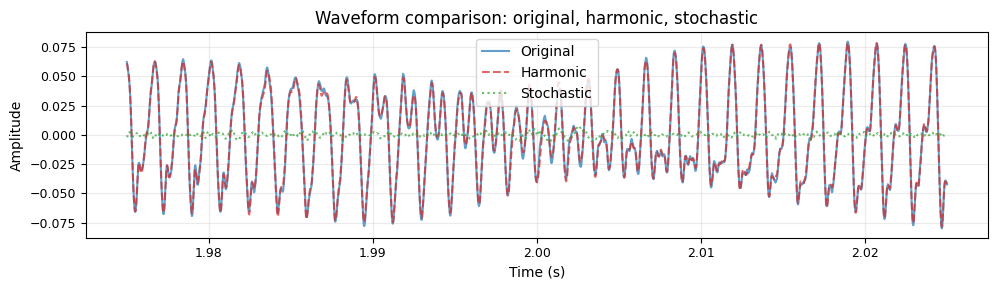

In [15]:
# Compare original, harmonic, and stochastic waveforms for a short section
section_time = 2.0  # seconds (center of the section)
section_dur = 0.05  # duration in seconds
center = int(section_time * fs)
half_len = int(section_dur * fs / 2)
start = max(center - half_len, 0)
end = min(center + half_len, len(x))

time_axis = np.arange(start, end) / fs
x_section = x[start:end]
yh_section = yh[start:end]
yst_section = yst[start:end]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_axis, x_section, label='Original', color='tab:blue', alpha=0.7)
ax.plot(time_axis, yh_section, label='Harmonic', color='tab:red', linestyle='--', alpha=0.7)
ax.plot(time_axis, yst_section, label='Stochastic', color='tab:green', linestyle=':', alpha=0.7)
ax.set_title('Waveform comparison: original, harmonic, stochastic')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()